<a href="https://colab.research.google.com/github/gireesh66/Brain_MRI_-Segmentation/blob/main/Brain_MRI__Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt

In [ ]:
! unzip "/content/Brain MRI Segmentation Dataset.zip"

In [3]:
import os
import shutil

source_dir = "/content/kaggle_3m"
images_dir = "/content/dataset/images"
masks_dir = "/content/dataset/masks"

os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

for folder in os.listdir(source_dir):
    folder_path = os.path.join(source_dir, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            if "_mask" in file:
                shutil.copy(file_path, os.path.join(masks_dir, file))
            else:
                shutil.copy(file_path, os.path.join(images_dir, file))

In [4]:
print("Images:", len(os.listdir(images_dir)))
print("Masks :", len(os.listdir(masks_dir)))

Images: 3929
Masks : 3929


In [5]:
import os

images_dir = "/content/dataset/images"
masks_dir = "/content/dataset/masks"

# Create mask dictionary
mask_dict = {}

for mask_name in os.listdir(masks_dir):
    key = mask_name.replace("_mask.tif", "")
    mask_dict[key] = os.path.join(masks_dir, mask_name)

image_list = []
mask_list = []

for img_name in os.listdir(images_dir):
    key = img_name.replace(".tif", "")

    if key in mask_dict:
        image_list.append(os.path.join(images_dir, img_name))
        mask_list.append(mask_dict[key])
    else:
        print("No mask for:", img_name)

print("Total matched pairs:", len(image_list))

Total matched pairs: 3929


In [6]:
for i in range(2):
    print(image_list[i], " ---> ", mask_list[i])

/content/dataset/images/TCGA_HT_A5RC_19990831_1.tif  --->  /content/dataset/masks/TCGA_HT_A5RC_19990831_1_mask.tif
/content/dataset/images/TCGA_FG_6692_20020606_1.tif  --->  /content/dataset/masks/TCGA_FG_6692_20020606_1_mask.tif


In [7]:
print(len(image_list), len(mask_list))

3929 3929


In [8]:
import numpy as np
from PIL import Image

IMG_HEIGHT = 128
IMG_WIDTH = 128

def load_image(path):
    img = Image.open(path)
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img = np.array(img)
    # Normalize image to [0, 1]
    img = img / 255.0
    return img

def load_mask(path):
    mask = Image.open(path).convert("L") # Convert to grayscale
    mask = mask.resize((IMG_WIDTH, IMG_HEIGHT))
    mask = np.array(mask)
    # Normalize mask to [0, 1] and then binarize it with a threshold
    mask = mask / 255.0
    mask = (mask > 0.5).astype(np.float32) # Binarize the mask
    mask = np.expand_dims(mask, axis=-1) # Add channel dimension
    return mask

X = []
y = []

for img_path, mask_path in zip(image_list, mask_list):
    X.append(load_image(img_path))
    y.append(load_mask(mask_path))

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(3929, 128, 128, 3)
(3929, 128, 128, 1)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

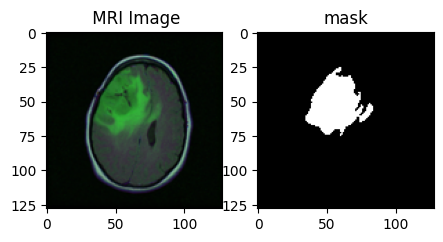

In [10]:
import matplotlib.pyplot as plt

i=2

plt.figure(figsize=(5,10))

plt.subplot(1,2,1)
plt.title(" MRI Image")
plt.imshow(X_train[i])



plt.subplot(1,2,2)
plt.title("mask")
plt.imshow(y_train[i].squeeze(), cmap='gray')


plt.show()


In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers


In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks for Early Stopping and Model Checkpoint
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,       # Number of epochs with no improvement after which training will be stopped.
    verbose=1,         # Log when training is stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

model_checkpoint = ModelCheckpoint(
    'unet_brain_segmentation.keras', # Path to save the model file.
    monitor='val_loss',             # Quantity to monitor.
    save_best_only=True,            # Only save when the monitored quantity is at its best.
    verbose=1
)

In [24]:
def unet_model(input_shape=(128, 128, 3)):

    inputs = layers.Input(input_shape)


    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)
    p1 = layers.Dropout(0.1)(p1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)
    p2 = layers.Dropout(0.1)(p2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)
    p3 = layers.Dropout(0.2)(p3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)
    p4 = layers.Dropout(0.2)(p4)


    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)
    c5 = layers.Dropout(0.3)(c5)


    u6 = layers.Conv2DTranspose(512, 2, strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)
    c6 = layers.Dropout(0.2)(c6)

    u7 = layers.Conv2DTranspose(128, 2, strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)
    c7 = layers.Dropout(0.2)(c7)

    u8 = layers.Conv2DTranspose(128, 2, strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)
    c8 = layers.Dropout(0.1)(c8)

    u9 = layers.Conv2DTranspose(64, 2, strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)
    c9 = layers.Dropout(0.1)(c9)


    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])

    return model

In [25]:
model = unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_3[

 Total params: 30,474,561 (116.25 MB)

 Trainable params: 30,474,561 (116.25 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# def dice_loss(y_true, y_pred, smooth=1e-6):
#     y_true_f = tf.keras.backend.flatten(y_true)
#     y_pred_f = tf.keras.backend.flatten(y_pred)
#     intersection = tf.reduce_sum(y_true_f * y_pred_f)

#     return 1 - (2. * intersection + smooth) / \
#            (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_coeff(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [27]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2. * intersection + 1e-6) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1e-6)

    return bce + (1 - dice)

In [28]:
model.compile(optimizer='adam',
              loss=bce_dice_loss,
              metrics=[dice_coeff, jaccard_index])

In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=100, # Increased epochs as early stopping will handle early termination
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - dice_coeff: 0.1571 - jaccard_index: 0.0956 - loss: 0.9998
Epoch 1: val_loss improved from None to 0.64042, saving model to unet_brain_segmentation.keras

Epoch 1: finished saving model to unet_brain_segmentation.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - dice_coeff: 0.3038 - jaccard_index: 0.1953 - loss: 0.7856 - val_dice_coeff: 0.4213 - val_jaccard_index: 0.2797 - val_loss: 0.6404
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - dice_coeff: 0.4775 - jaccard_index: 0.3237 - loss: 0.5750
Epoch 2: val_loss improved from 0.64042 to 0.43534, saving model to unet_brain_segmentation.keras

Epoch 2: finished saving model to unet_brain_segmentation.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - dice_coeff: 0.5082 - jaccard_index: 0.3509 - loss: 0.5413 - val_dice_coeff: 0.6031 - val_jaccard_index: 0.4375 - val_loss: 0.4353
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - dice_coeff: 0.5383 - jaccard_index: 0.3786 - loss:

In [41]:
pred = model.predict(X_test)
pred_bin = (pred > 0.5).astype("float32")

print("Dice:", dice_coeff (y_test, pred_bin).numpy())
print("Jaccard:", jaccard_index(y_test, pred_bin).numpy())

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step
Dice: 0.90329355
Jaccard: 0.823642


In [33]:
pred = model.predict(X_test)
Accuracy = model.evaluate(X_test, y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - dice_coeff: 0.9013 - jaccard_index: 0.8210 - loss: 0.1097


In [36]:
pred_binary = (pred > 0.2).astype("float32")

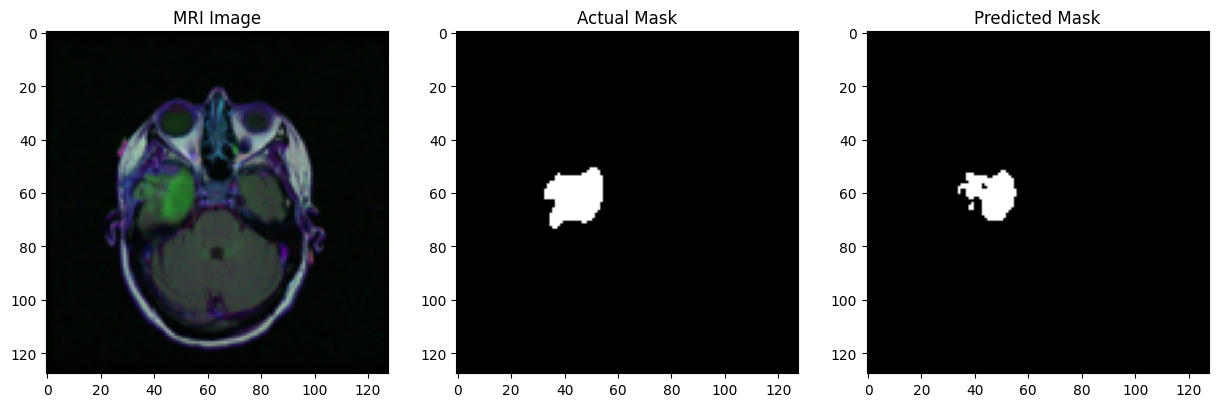

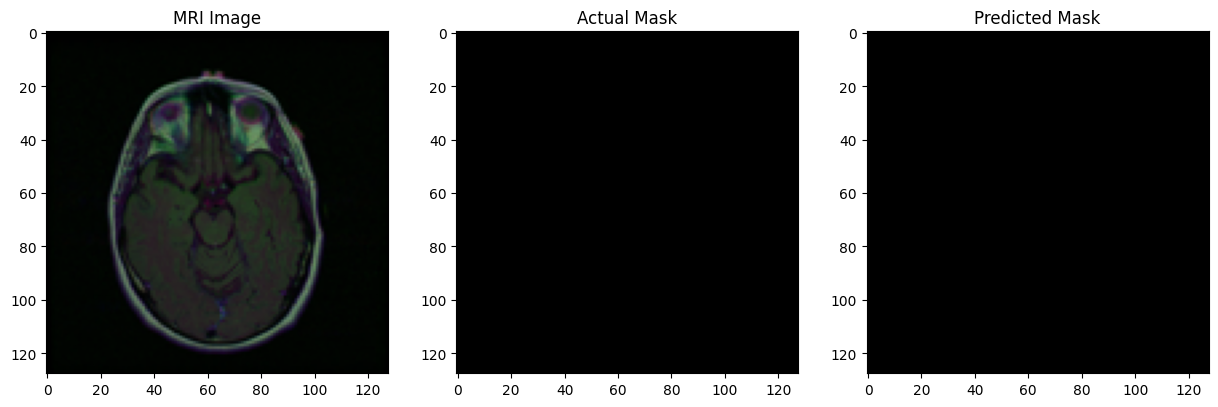

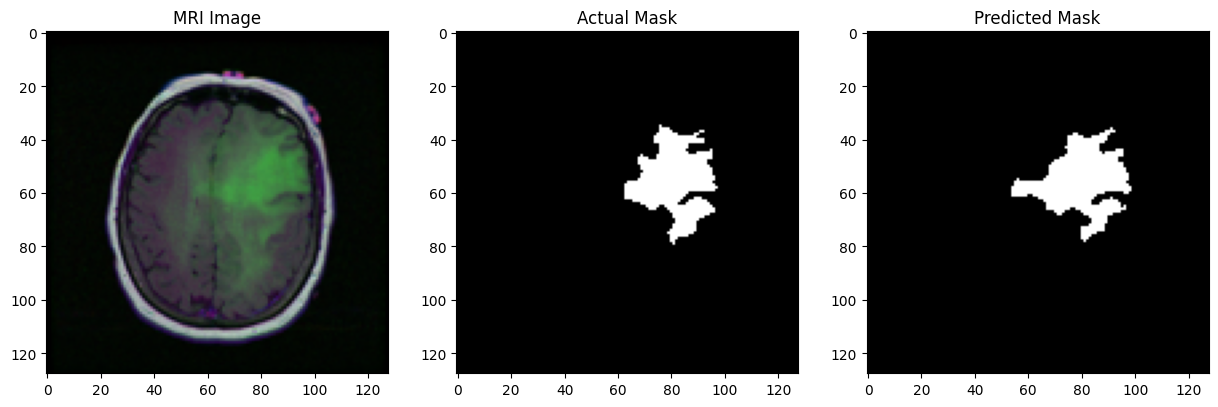

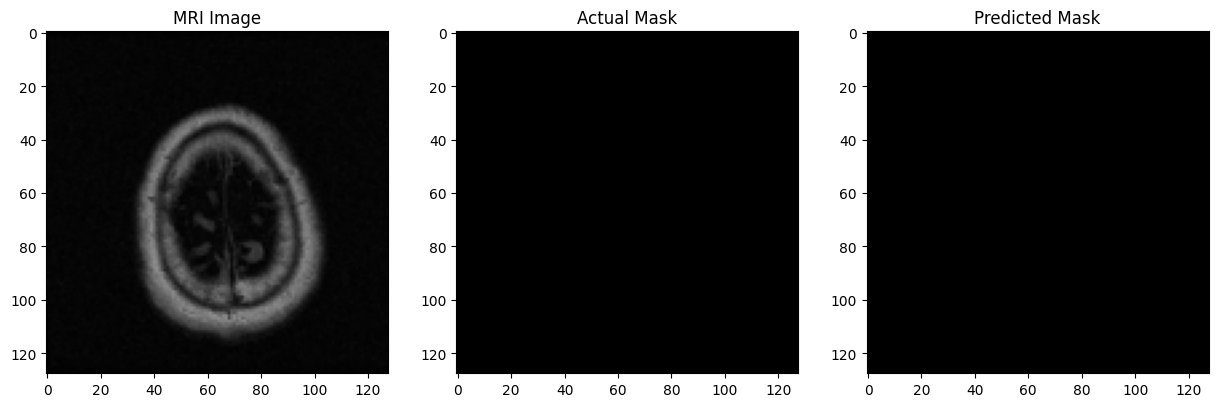

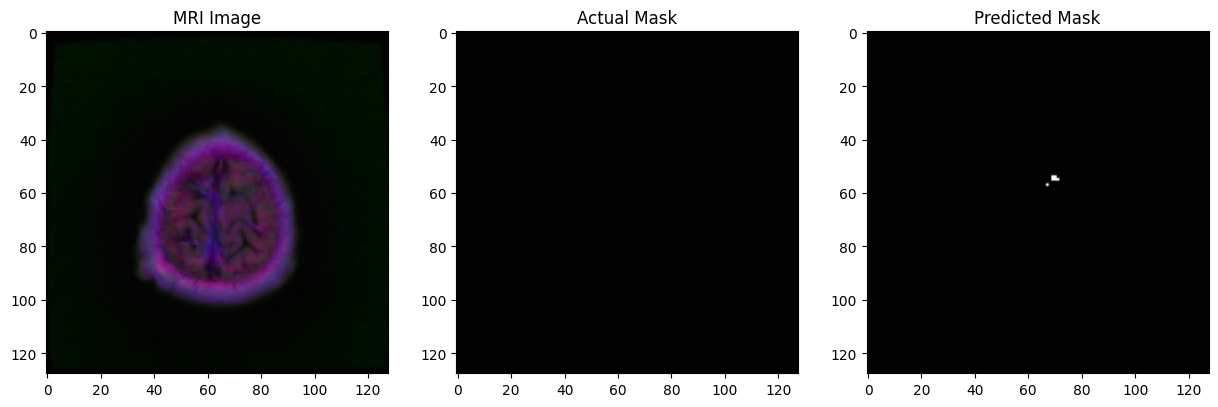

In [48]:
import matplotlib.pyplot as plt
import random

# Generate 5 random indices from the test set
random_indices = random.sample(range(len(X_test)), 5)

for i in random_indices:
    plt.figure(figsize=(15,5))

    # ▓▓ Original Image
    plt.subplot(1,3,1)
    plt.title("MRI Image")
    plt.imshow(X_test[i])

    # ▓▓ Ground Truth
    plt.subplot(1,3,2)
    plt.title("Actual Mask")
    plt.imshow(y_test[i].squeeze(), cmap='gray')

    # ▓▓ Predicted Mask
    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(pred_binary[i].squeeze(), cmap='gray')

    plt.show()

In [45]:
print(history.history.keys())

dict_keys(['dice_coeff', 'jaccard_index', 'loss', 'val_dice_coeff', 'val_jaccard_index', 'val_loss'])


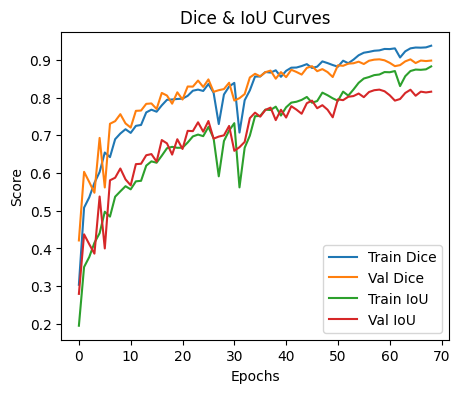

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

# Dice
plt.plot(history.history['dice_coeff'], label='Train Dice')
plt.plot(history.history['val_dice_coeff'], label='Val Dice')

# Jaccard (IoU)
plt.plot(history.history['jaccard_index'], label='Train IoU')
plt.plot(history.history['val_jaccard_index'], label='Val IoU')

plt.title("Dice & IoU Curves")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()

plt.show()